In [ ]:
import numpy as np
from scipy.stats import gamma
import seaborn as sns
from generating_dataset import dataset,true_beta
from palette import palette
import matplotlib.pyplot as plt
from utils_lasso import standarized_centered_X_y, bayesian_lasso_hyp, bayesian_lasso_em
import matplotlib.ticker as ticker
from sklearn.linear_model import Lasso
import pandas as pd


In [ ]:
X,y = dataset
n,p = X.shape[0],X.shape[1]-1
X_stdized,y_tilde = standarized_centered_X_y(X,y)

### Calculate lambda_0

In [ ]:
XtX_inv = np.linalg.pinv(X_stdized.T @ X_stdized)
beta_0 = XtX_inv @ X_stdized.T @ y_tilde

residuals_ols = y_tilde - X_stdized @ beta_0
sigma2_0 = (residuals_ols.T @ residuals_ols) / (n - p - 1)

sum_abs_beta = np.sum(np.abs(beta_0))
lambda_curr = (p * np.sqrt(sigma2_0)) / sum_abs_beta
lambda_sq_0 = lambda_curr**2

### <b> Run both methods

In [ ]:
lambda_0 = np.sqrt(lambda_sq_0)
results_hyp = bayesian_lasso_hyp(y_tilde,X_stdized,r=1,delta=1/lambda_0,T=11000,B=1000)

In [ ]:
results_eb = bayesian_lasso_em(y_tilde, X_stdized,epsilon=1e-3, M=1000, K=100, T=11000, B=1000)

 -> EM Converged at iteration k=11 to lambda=2.5630
Starting Phase 2: Posterior Inference (T=11000 iterations)...


### Calculate estimated_sigma^2 for last graphic

In [ ]:
estimated_sigma2=np.mean(results_eb["sigma2_samples"])
estimated_sigma2

6.552794894830564

### <b> Coefficients distributions

In [ ]:
beta_samples_hyp = results_hyp["beta"]
beta_samples_eb = results_eb["beta_samples"]

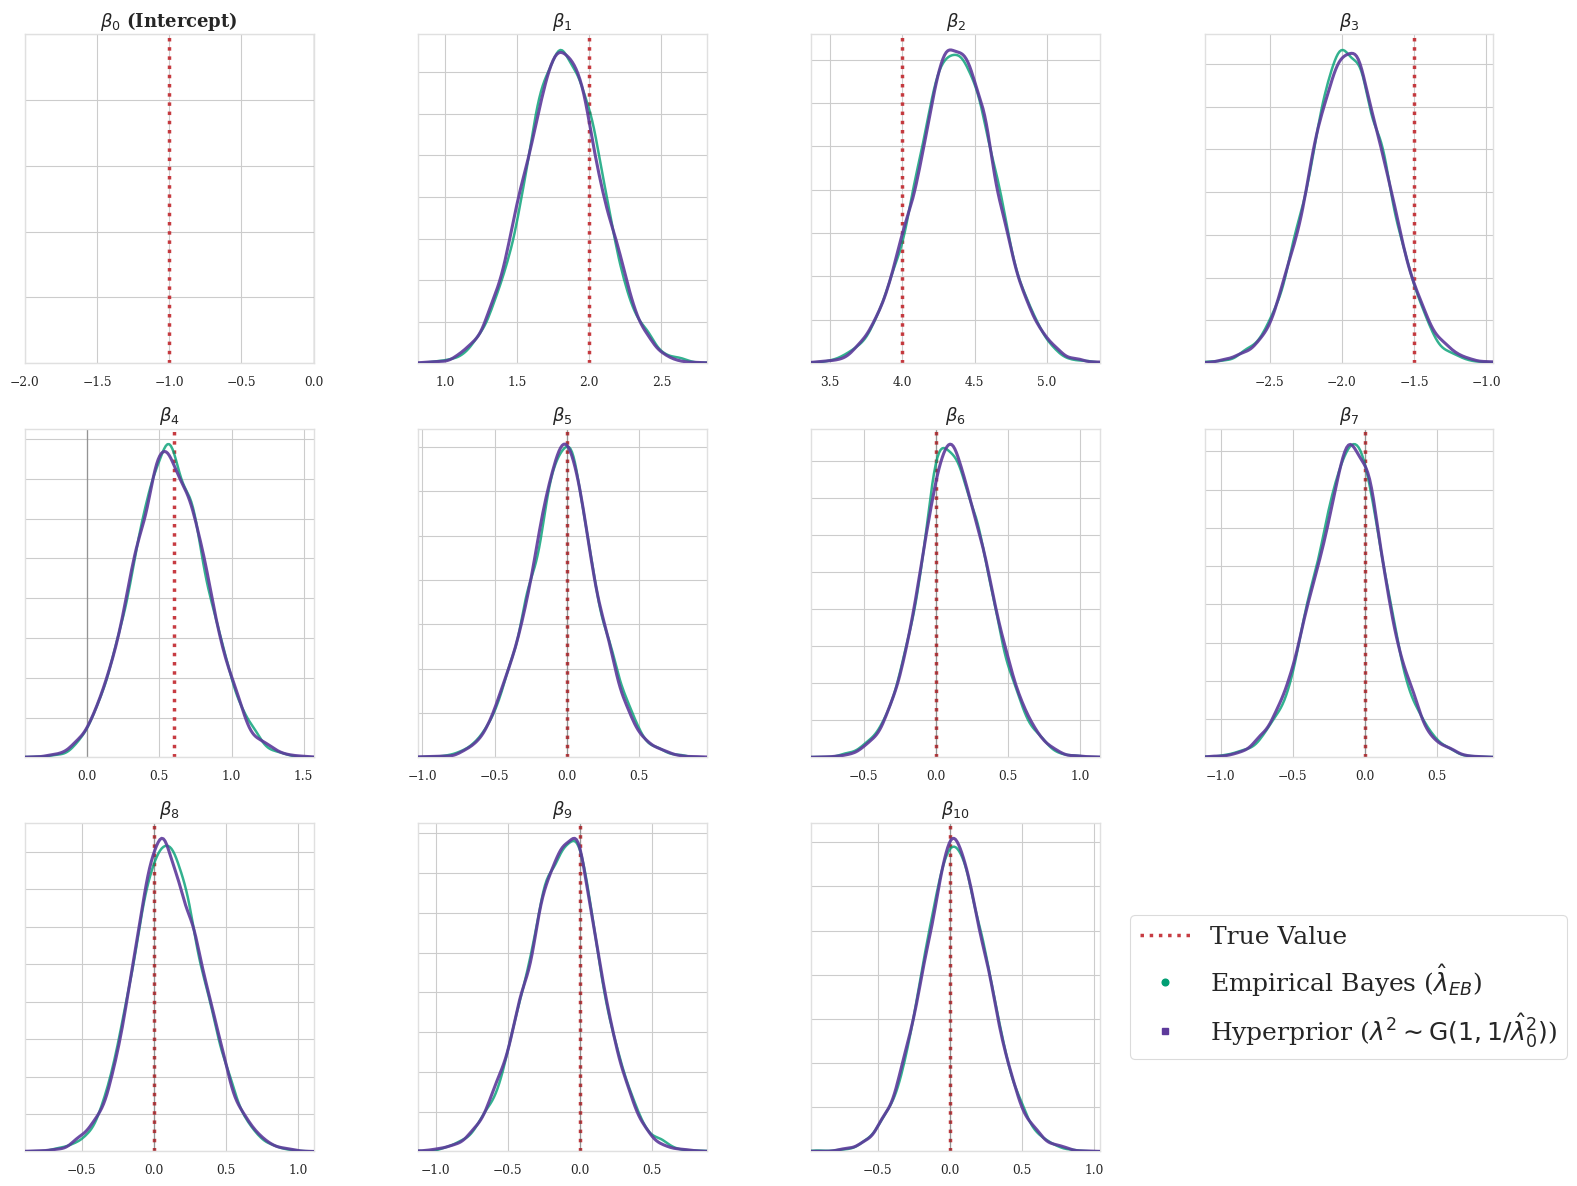

In [ ]:
sns.set_theme(style="whitegrid", context="paper", font="serif")
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold'})
grid_gray = "#E0E0E0" 


window_radius = 1.0
num_vars = beta_samples_hyp.shape[1] 

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i in range(num_vars + 1):
    ax = axes[i]
    
    if i == 0:
        true_val = true_beta[0]
        samples_eb = np.array([])
        samples_hyp = np.array([])
        titulo = r"$\boldsymbol{\beta_{0}}$ (Intercept)"
    else:
        true_val = true_beta[i]
        samples_eb = beta_samples_eb[:, i-1]
        samples_hyp = beta_samples_hyp[:, i-1]
        titulo = rf"$\boldsymbol{{\beta_{{{i}}}}}$"

    current_center = np.mean(samples_hyp) if len(samples_hyp) > 0 else true_val

    ax.axvline(true_val, color=palette.true_red, linestyle=':', linewidth=2.5, 
                alpha=0.9, zorder=1, label='True Value')
    ax.axvline(0, color=palette.zero_gray, linestyle='-', alpha=0.4, linewidth=1, zorder=2)

    if len(samples_eb) > 0:
        ax.errorbar([], [], fmt='o', color=palette.lasso_em, label=r'Empirical Bayes ($\hat\lambda_{EB}$)') 
        sns.kdeplot(samples_eb, ax=ax, color=palette.lasso_em, linewidth=1.8, 
                    fill=False, alpha=0.8, zorder=3)

    if len(samples_hyp) > 0:
        label_hyp = r'Hyperprior ($\lambda^2 \sim \text{G}(1, 1/\hat{\lambda}_0^2)$)'
        ax.errorbar([], [], fmt='s', color=palette.lasso_hyp, label=label_hyp) 
        sns.kdeplot(samples_hyp, ax=ax, color=palette.lasso_hyp, linewidth=2.2, 
                    fill=False, alpha=0.9, zorder=4)

    ax.set_xlim(current_center - window_radius, current_center + window_radius)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    
    ax.set_title(titulo, fontsize=13)
    ax.set_ylim(bottom=0)
    ax.set_ylabel('')  
    ax.tick_params(axis='y', labelleft=False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(grid_gray)
        spine.set_linewidth(1.0)

# Legend
for j in range(num_vars + 1, len(axes)):
    axes[j].axis('off')
    if j == len(axes) - 1:
        handles, labels = axes[1].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        axes[j].legend(by_label.values(), by_label.keys(), loc='center', 
                        fontsize=18, frameon=True, edgecolor='#D3D3D3', facecolor='white')

plt.tight_layout()
plt.savefig("../graphics/posteriors_lasso.pdf")
plt.show()


### <b> Credible intervals for both approaches

In [ ]:
def get_stats(samples):
    medians = np.median(samples, axis=0)
    
    lower = np.percentile(samples, 2.5, axis=0)
    upper = np.percentile(samples, 97.5, axis=0)
    
    errors = np.array([medians - lower, upper - medians])
    return medians, errors

# Empirical Bayes
mean_eb, err_eb = get_stats(results_eb['beta_samples'])

# Hyperprior
mean_hyp, err_hyp = get_stats(results_hyp['beta'])

true_values = true_beta[1:] if len(true_beta) > 10 else true_beta

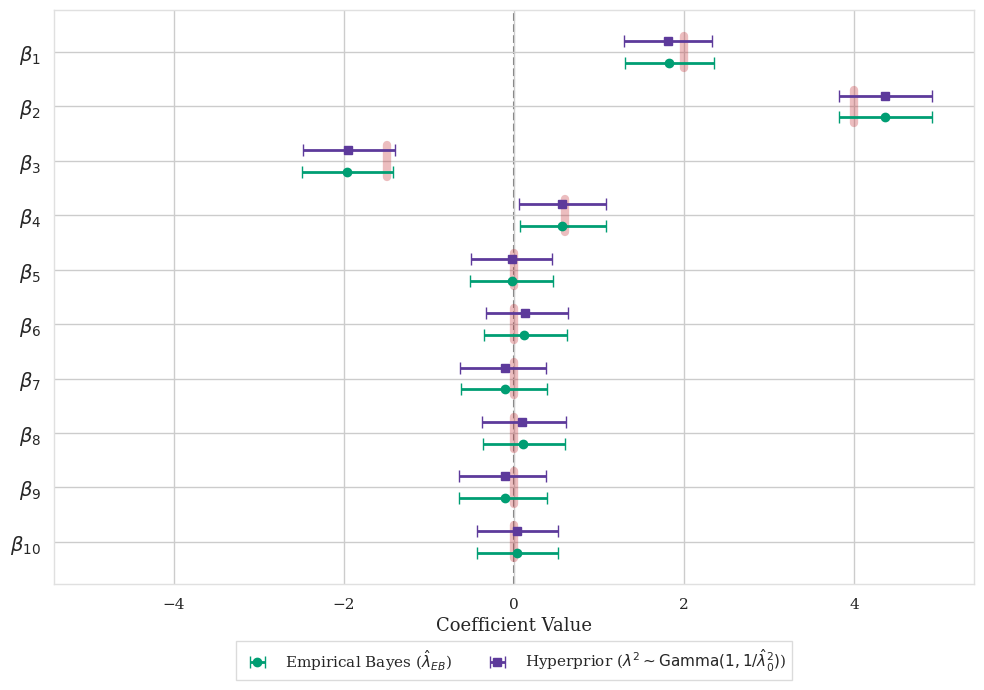

In [ ]:
sns.set_theme(style="whitegrid", font="serif")
fig, ax = plt.subplots(figsize=(10, 7))


p = mean_eb.shape[0] 
y_pos = np.arange(p)
offset = 0.2  

# A. True value
for i in range(p):
    ax.plot([true_values[i], true_values[i]], [y_pos[i]-0.3, y_pos[i]+0.3], 
            color=palette.true_red, alpha=0.3, linewidth=6, zorder=1)

# B. Empirical Bayes
ax.errorbar(mean_eb, y_pos + offset, xerr=err_eb, fmt='o', 
            color=palette.lasso_em, linewidth=2, capsize=4, 
            label='Empirical Bayes ($\hat\lambda_{EB}$)')

# C. Hyperprior
ax.errorbar(mean_hyp, y_pos - offset, xerr=err_hyp, fmt='s', 
            color=palette.lasso_hyp, linewidth=2, capsize=4, 
            label=r'Hyperprior ($\lambda^2 \sim \text{Gamma}(1, 1/\hat{\lambda}_0^2)$)')

# zero
ax.axvline(0, color=palette.zero_gray, linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


all_values = np.concatenate([mean_eb + err_eb[1], mean_eb - err_eb[0], 
                             mean_hyp + err_hyp[1], mean_hyp - err_hyp[0],
                             true_values])
max_abs = np.max(np.abs(all_values))
padding = 1.1 
ax.set_xlim(-max_abs * padding, max_abs * padding)


for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(grid_gray) 
    spine.set_linewidth(1.0)


ax.set_yticks(y_pos)
ax.set_yticklabels([f"$\\boldsymbol{{\\beta_{{{i+1}}}}}$" for i in range(p)], fontsize=14)
ax.invert_yaxis() 

ax.set_xlabel("Coefficient Value", fontsize=13)

# Legend setup
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=11, 
           frameon=True, edgecolor='#D3D3D3', fancybox=False)

plt.tight_layout()
plt.savefig("../graphics/bayesian_lasso_ci.pdf")
plt.show()

### <B> Malick Mixed appraoch

In [ ]:
lambda_eb = results_eb["lambda_EB"]
lambda_eb

2.5629952648525993

In [ ]:
sigma_sample = np.sqrt(estimated_sigma2)

n = 100
lambda_bayesian_em = 2.56

alpha_scaled = (lambda_bayesian_em * sigma_sample) / n

print(f"Mixed Approach Configuration:")
print(f"  > Estimated sigma (sqrt(estimated_sigma2)): {sigma_sample:.4f}")
print(f"  > Scaled alpha for sklearn: {alpha_scaled:.5f}\n")

y_tilde = y - np.mean(y)
X_stdized = X[:, 1:]

lasso_mixed = Lasso(alpha=alpha_scaled, fit_intercept=False, max_iter=10000)
lasso_mixed.fit(X_stdized, y_tilde)

coefficients = lasso_mixed.coef_
true_betas = [2.0, 4.0, -1.5, 0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

df_comparison = pd.DataFrame({
    'Variable': [f'Beta_{i+1}' for i in range(len(coefficients))],
    'True Value': true_betas,
    'Mixed Estimate': coefficients,
    'Status': ['Relevant' if abs(v) > 1e-10 else 'COLLAPSED TO ZERO' for v in coefficients]
})

print("--- FINAL RESULTS: MIXED APPROACH ---")
print(df_comparison)

discarded_variables = np.where(np.abs(coefficients) < 1e-10)[0] + 1
print(f"\nVariables discarded by the model (coefficient = 0): {discarded_variables.tolist()}")

Mixed Approach Configuration:
  > Estimated sigma (sqrt(estimated_sigma2)): 2.5598
  > Scaled alpha for sklearn: 0.06553

--- FINAL RESULTS: MIXED APPROACH ---
  Variable  True Value  Mixed Estimate             Status
0   Beta_1         2.0        1.827164           Relevant
1   Beta_2         4.0        4.392612           Relevant
2   Beta_3        -1.5       -1.922599           Relevant
3   Beta_4         0.6        0.550364           Relevant
4   Beta_5         0.0       -0.000000  COLLAPSED TO ZERO
5   Beta_6         0.0        0.071047           Relevant
6   Beta_7         0.0       -0.038880           Relevant
7   Beta_8         0.0        0.065965           Relevant
8   Beta_9         0.0       -0.061967           Relevant
9  Beta_10         0.0        0.000000  COLLAPSED TO ZERO

Variables discarded by the model (coefficient = 0): [5, 10]
